In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


df = pd.read_csv("heart_statlog_cleveland_hungary_final.csv")

df.columns = [c.strip().replace(" ", "_") for c in df.columns]

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (1190, 12)
   age  sex  chest_pain_type  resting_bp_s  cholesterol  fasting_blood_sugar  \
0   40    1                2           140          289                    0   
1   49    0                3           160          180                    0   
2   37    1                2           130          283                    0   
3   48    0                4           138          214                    0   
4   54    1                3           150          195                    0   

   resting_ecg  max_heart_rate  exercise_angina  oldpeak  ST_slope  target  
0            0             172                0      0.0         1       0  
1            0             156                0      1.0         2       1  
2            1              98                0      0.0         1       0  
3            0             108                1      1.5         2       1  
4            0             122                0      0.0         1       0  
<class 'pandas.core.frame.DataFrame'>
R

In [2]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age                    0
sex                    0
chest_pain_type        0
resting_bp_s           0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
ST_slope               0
target                 0
dtype: int64


In [3]:
print("Cholesterol = 0 count:", (df["cholesterol"] == 0).sum())
print("Resting BP = 0 count :", (df["resting_bp_s"] == 0).sum())

Cholesterol = 0 count: 172
Resting BP = 0 count : 1


In [4]:
df["cholesterol"] = df["cholesterol"].replace(0, np.nan)
df["resting_bp_s"] = df["resting_bp_s"].replace(0, np.nan)

df["cholesterol"].fillna(df["cholesterol"].median(), inplace=True)
df["resting_bp_s"].fillna(df["resting_bp_s"].median(), inplace=True)

print("After cleaning -> missing values:", df.isnull().sum().sum())

After cleaning -> missing values: 0


C:\Users\sawera tahir\AppData\Local\Temp\ipykernel_11976\621258292.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["cholesterol"].fillna(df["cholesterol"].median(), inplace=True)
C:\Users\sawera tahir\AppData\Local\Temp\ipykernel_11976\621258292.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [5]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Duplicates removed: {before - after}")
print("New shape:", df.shape)

Duplicates removed: 272
New shape: (918, 12)


In [6]:
num_cols = ["age", "resting_bp_s", "cholesterol", "max_heart_rate", "oldpeak"]

for c in num_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df[c] = np.clip(df[c], low, high)

print("Outliers capped successfully")

Outliers capped successfully


In [7]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

print(df_scaled[num_cols].describe().round(2))

          age  resting_bp_s  cholesterol  max_heart_rate  oldpeak
count  918.00        918.00       918.00          918.00   918.00
mean    -0.00         -0.00         0.00           -0.00     0.00
std      1.00          1.00         1.00            1.00     1.00
min     -2.71         -2.49        -2.38           -2.79    -3.03
25%     -0.69         -0.72        -0.62           -0.66    -0.85
50%      0.05         -0.13        -0.04            0.05    -0.27
75%      0.69          0.46         0.56            0.75     0.60
max      2.49          2.23         2.33            2.56     2.79


In [8]:
print(df_scaled.head())

        age  sex  chest_pain_type  resting_bp_s  cholesterol  \
0 -1.433140    1                2      0.462639     1.048947   
1 -0.478484    0                3      1.644173    -1.372856   
2 -1.751359    1                2     -0.128128     0.915637   
3 -0.584556    0                4      0.344485    -0.617431   
4  0.051881    1                3      1.053406    -1.039580   

   fasting_blood_sugar  resting_ecg  max_heart_rate  exercise_angina  \
0                    0            0        1.384080                0   
1                    0            0        0.754610                0   
2                    0            1       -1.527219                0   
3                    0            0       -1.133801                1   
4                    0            0       -0.583014                0   

    oldpeak  ST_slope  target  
0 -0.851276         1       0  
1  0.118532         2       1  
2 -0.851276         1       0  
3  0.603436         2       1  
4 -0.851276         1 

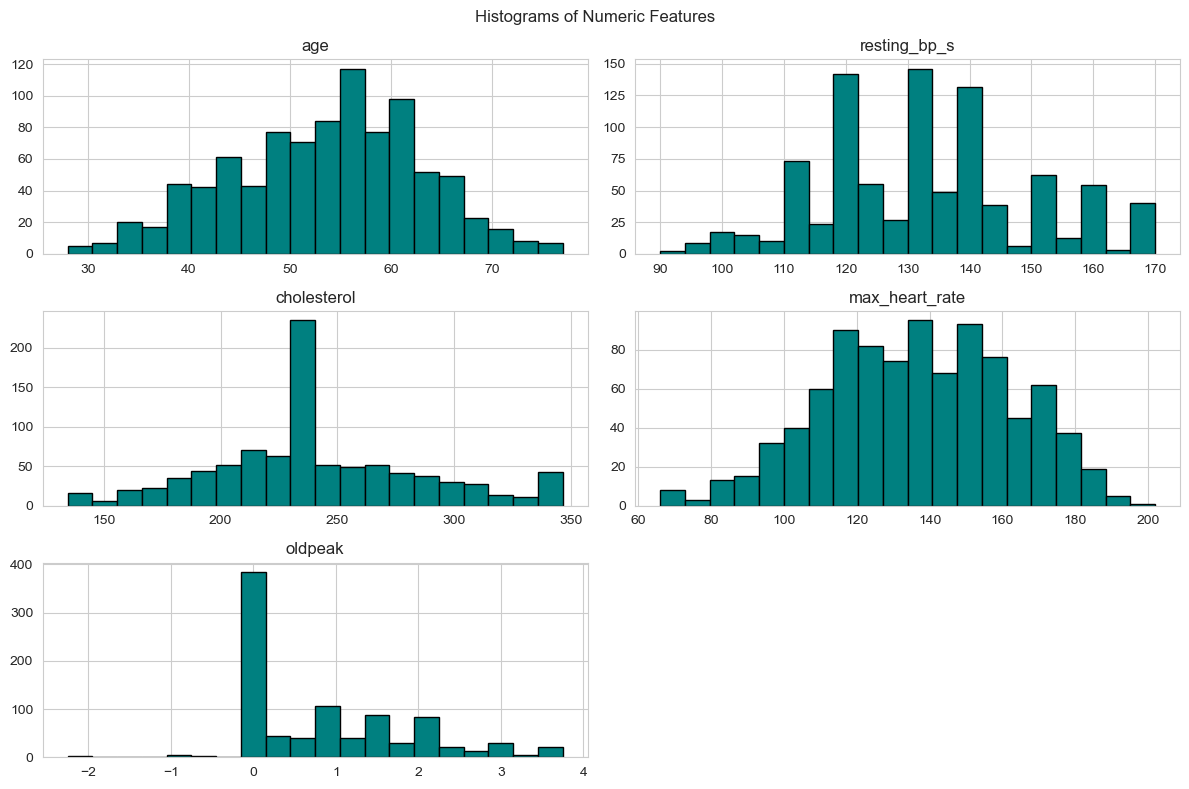

In [9]:
#Exploratory Data Analysis (EDA)
df[num_cols].hist(figsize=(12, 8), bins=20, color="teal", edgecolor="black")
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()

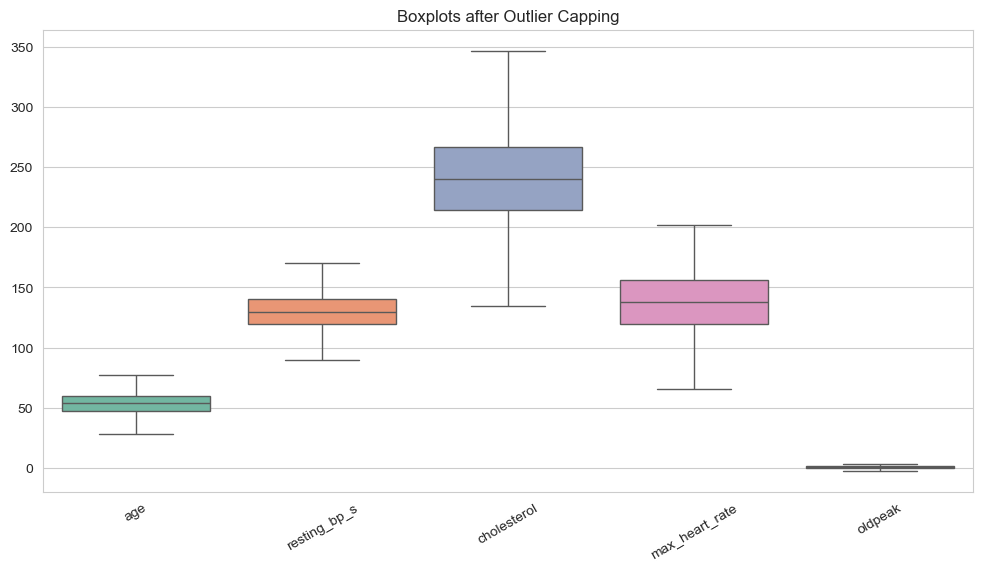

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], palette="Set2")
plt.title("Boxplots after Outlier Capping")
plt.xticks(rotation=30)
plt.show()

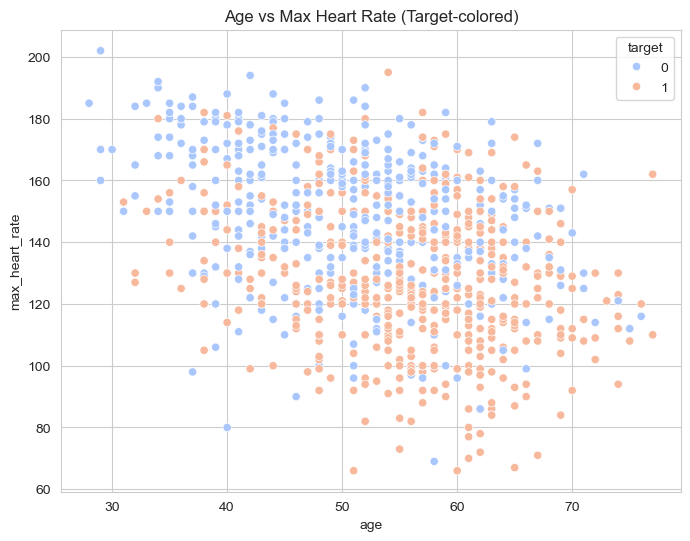

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="age", y="max_heart_rate",
                hue="target", palette="coolwarm")
plt.title("Age vs Max Heart Rate (Target-colored)")
plt.show()

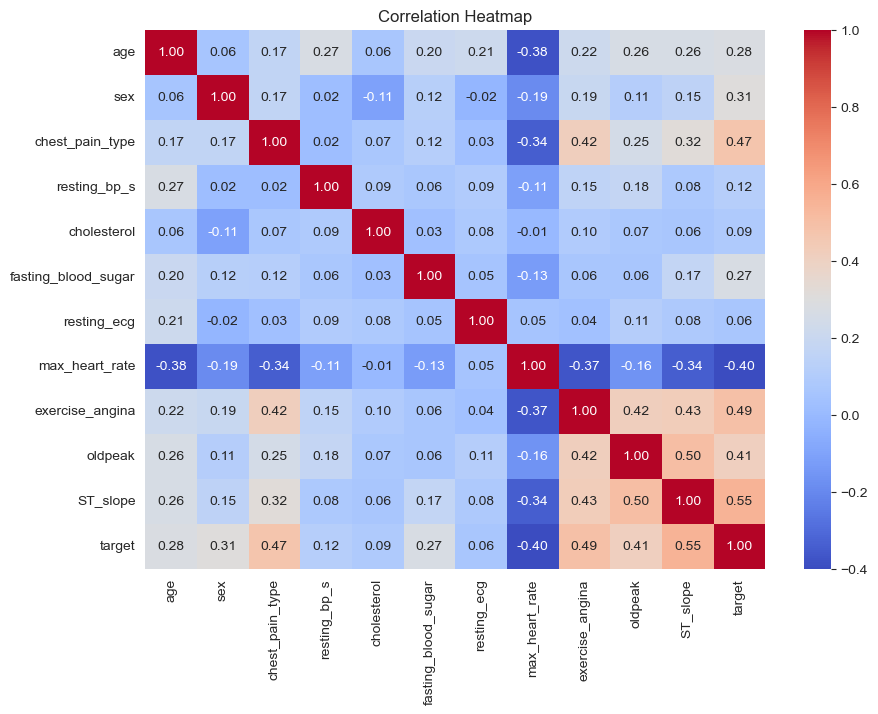

In [12]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

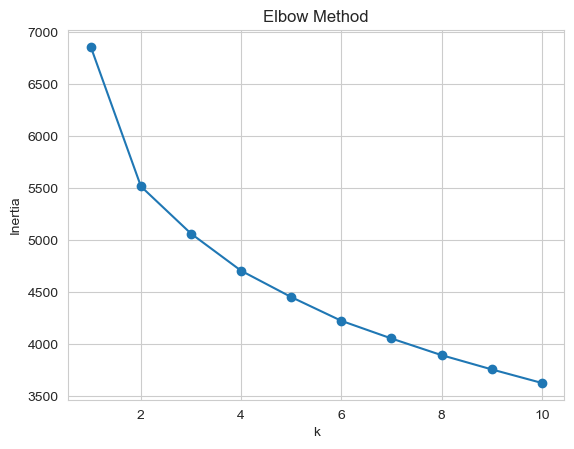

Cluster
1    348
0    291
2    279
Name: count, dtype: int64


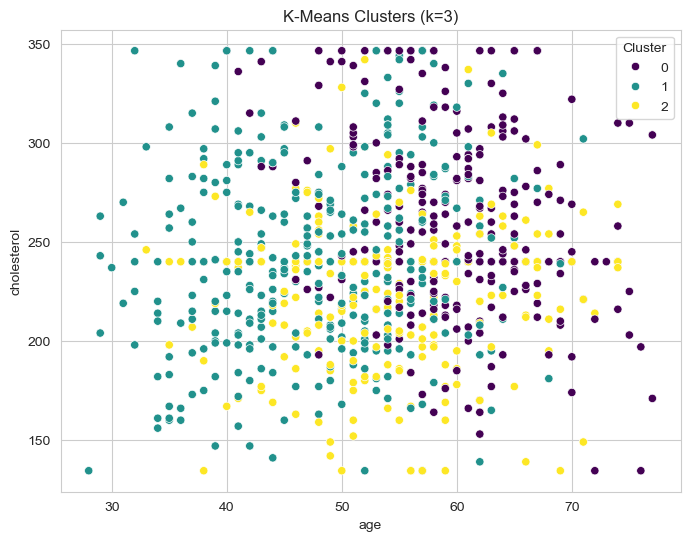

In [13]:
X_cluster = df_scaled.drop("target", axis=1)

# Elbow method to pick k
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("k"); plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Apply K-Means with k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = km.fit_predict(X_cluster)

print(df["Cluster"].value_counts())

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="age", y="cholesterol",
                hue="Cluster", palette="viridis")
plt.title("K-Means Clusters (k=3)")
plt.show()

In [14]:
X = df.drop(["target", "Cluster"], axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

# Random Forest
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

# Confusion matrix + report for best model
print("\nConfusion Matrix (RF):")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report (RF):")
print(classification_report(y_test, rf_pred))

Logistic Regression Accuracy: 0.8586956521739131
Random Forest Accuracy: 0.8804347826086957

Confusion Matrix (RF):
[[70 12]
 [10 92]]

Classification Report (RF):
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [15]:
joblib.dump(rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model & scaler saved ✅")

Model & scaler saved ✅
